# [(O Problema, Variável-Alvo e o Negócio)]

In [1]:
import os

# Descobre o nome da pasta onde o notebook está rodando agora
pasta_atual = os.path.basename(os.getcwd())

# Se o notebook ainda estiver dentro da pasta 'notebooks', ele dá um passo para trás
if pasta_atual == 'notebooks':
    os.chdir('..')

# Imprime o caminho para confirmar que deu certo
print(f"✅ Diretório raiz configurado para: {os.getcwd()}")

✅ Diretório raiz configurado para: /Users/henriquegoulartdasilveira/spotify_dataview


In [2]:
import sys
import os
from pathlib import Path

# Descobre onde o notebook está agora
caminho_notebook = Path(os.getcwd()).resolve()

# Força o caminho para a raiz (subindo um nível caso ele esteja em 'notebooks')
if caminho_notebook.name == 'notebooks':
    raiz = str(caminho_notebook.parent)
else:
    raiz = str(caminho_notebook)

# Adicionamos tanto a raiz quanto a própria pasta src no mapa do Python
if raiz not in sys.path:
    sys.path.insert(0, raiz)
if str(Path(raiz) / "src") not in sys.path:
    sys.path.insert(0, str(Path(raiz) / "src"))

os.chdir(raiz)
print(f"📍 Pasta raiz travada em: {raiz}")
print(f"📂 Arquivos que o Python está vendo aqui na raiz: {os.listdir(raiz)}")

📍 Pasta raiz travada em: /Users/henriquegoulartdasilveira/spotify_dataview
📂 Arquivos que o Python está vendo aqui na raiz: ['.DS_Store', 'LICENSE', 'requirements.txt', 'models', 'README.md', '.gitignore', '.git', 'data', 'outputs', 'notebooks', 'src']


In [3]:
# [Importações]
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from src.config import MODEL_FILE, METRICS_FILE, DATA_RAW_PATH, DATA_PROCESSED_PATH, DATA_FINAL_PATH
from src.dataset import load_raw_data, save_processed_data
from src.features import clean_data, feature_engineering, prepare_for_model
from src.plots import plot_target_distribution, plot_correlation_heatmap
from src.modeling.train import train_and_evaluate_model, save_model_and_metrics

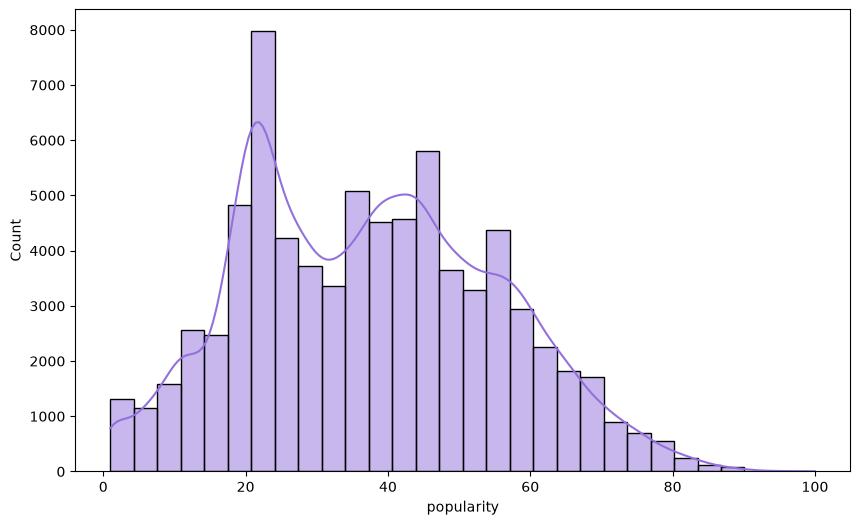

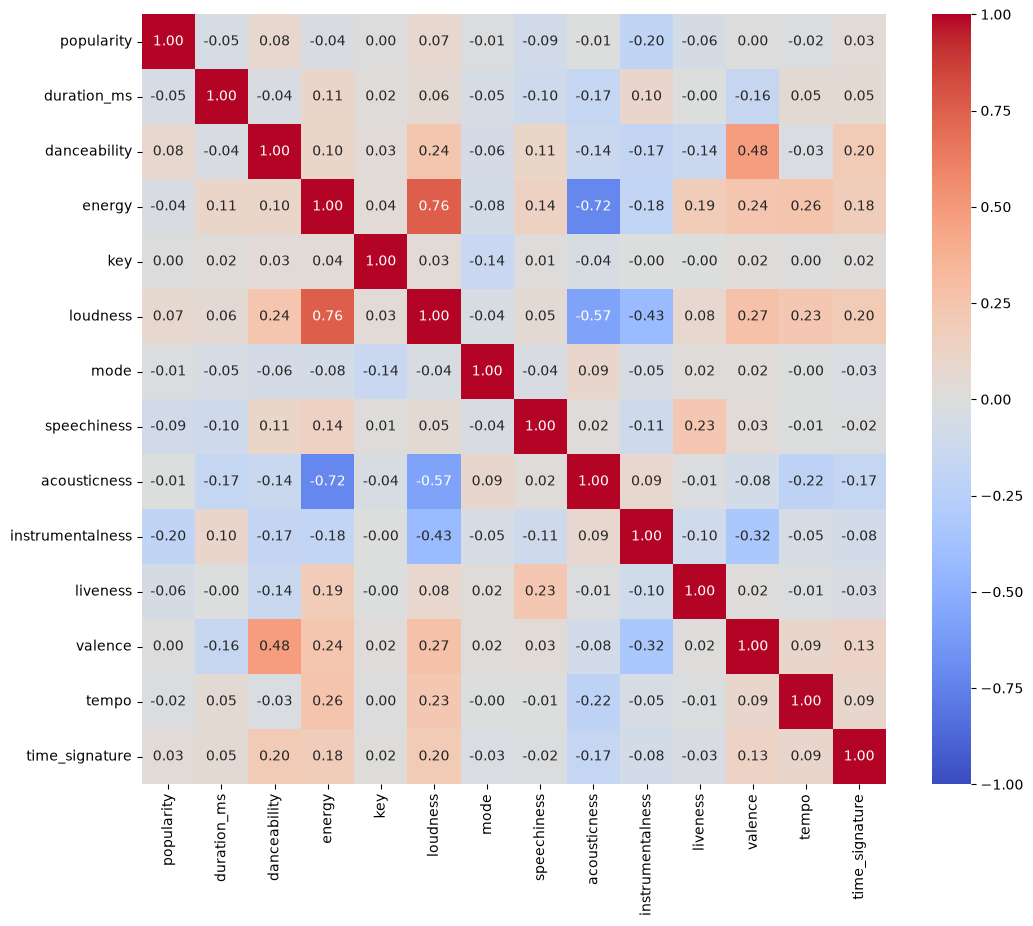

In [4]:
# [Fases 1 e 2 - EDA e Data Prep]
df_raw = load_raw_data(DATA_RAW_PATH)
df_clean = clean_data(df_raw)
save_processed_data(df_clean, DATA_PROCESSED_PATH) # Salvando o histórico limpo
plot_target_distribution(df_clean)
plot_correlation_heatmap(df_clean)

In [5]:
print("📊 --- RAIO-X DOS DADOS BRUTOS (df_raw) ---")
display(df_raw.describe().round(2))

print("\n🧹 --- RAIO-X DOS DADOS LIMPOS (df_clean) ---")
display(df_clean.describe().round(2))

📊 --- RAIO-X DOS DADOS BRUTOS (df_raw) ---


,Unnamed: 0.1,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00
mean,56999.50,56999.50,33.24,228029.15,0.57,0.64,5.31,-8.26,0.64,0.08,0.31,0.16,0.21,0.47,122.15,3.90
std,32909.11,32909.11,22.31,107297.71,0.17,0.25,3.56,5.03,0.48,0.11,0.33,0.31,0.19,0.26,29.98,0.43
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-49.53,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,28499.75,28499.75,17.00,174066.00,0.46,0.47,2.00,-10.01,0.00,0.04,0.02,0.00,0.10,0.26,99.22,4.00
50%,56999.50,56999.50,35.00,212906.00,0.58,0.68,5.00,-7.00,1.00,0.05,0.17,0.00,0.13,0.46,122.02,4.00
75%,85499.25,85499.25,50.00,261506.00,0.70,0.85,8.00,-5.00,1.00,0.08,0.60,0.05,0.27,0.68,140.07,4.00
max,113999.00,113999.00,100.00,5237295.00,0.98,1.00,11.00,4.53,1.00,0.96,1.00,1.00,1.00,1.00,243.37,5.00



🧹 --- RAIO-X DOS DADOS LIMPOS (df_clean) ---


,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,75852.00,75852.00,75852.00,75852.00,75852.00,75852.00,75852.00,75852.00,75852.00,75852.00,75852.00,75852.00,75852.00,75852.00
mean,37.53,225724.24,0.56,0.64,5.29,-8.46,0.63,0.09,0.32,0.18,0.22,0.47,122.46,3.90
std,17.83,81791.07,0.18,0.25,3.56,5.16,0.48,0.12,0.33,0.33,0.20,0.26,30.09,0.45
min,1.00,24266.00,0.00,0.00,0.00,-49.53,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,23.00,173528.25,0.45,0.46,2.00,-10.28,0.00,0.04,0.02,0.00,0.10,0.25,99.91,4.00
50%,37.00,214946.00,0.58,0.68,5.00,-7.21,1.00,0.05,0.18,0.00,0.13,0.45,122.39,4.00
75%,51.00,266000.00,0.69,0.86,8.00,-5.12,1.00,0.09,0.61,0.13,0.28,0.68,140.90,4.00
max,100.00,555007.00,0.98,1.00,11.00,4.53,1.00,0.96,1.00,1.00,1.00,1.00,243.37,5.00


In [6]:
# [Fases 3 e 4 - Feature Engineering e Preparação]
df_features = feature_engineering(df_clean)
df_final = prepare_for_model(df_features)
save_processed_data(df_final, DATA_FINAL_PATH) # Salvando o final

X, y = df_final.drop(columns=['popularity']), df_final['popularity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled, X_test_scaled = scaler.fit_transform(X_train), scaler.transform(X_test)

In [7]:
# [Fases 5 e 6 - Modelagem e Exportação]

# 1. Treina e avalia a Abordagem 1 (Popularidade)
modelo_rf_pop, metricas_pop = train_and_evaluate_model(X_train_scaled, y_train, X_test_scaled, y_test)
print("📊 Métricas - Popularidade (Abordagem 1):", metricas_pop)



📊 Métricas - Popularidade (Abordagem 1): {'MAE_treino': 12.36, 'MAE_teste': 13.0, 'RMSE_teste': 16.11, 'R2_teste': 0.1746}


# 🕺 Parte 2: Mudança de Alvo - Prevendo a Dançabilidade (danceability)

Já que descobrimos que a popularidade depende de fatores externos, vamos mudar nosso foco para uma métrica puramente musical. 
A `danceability` é calculada pelo Spotify usando o ritmo, estabilidade da batida e energia. Nosso modelo deve se sair muito melhor aqui!

In [ ]:
# [Preparação para Dançabilidade]


df_dance = df_clean.copy() 

# Separar os recursos (X) e o novo alvo (y)
# Removemr colunas de texto (IDs, nomes) e 'danceability'
colunas_excluir = ['track_id', 'artists', 'album_name', 'track_name', 'track_genre', 'danceability']
X_dance = df_dance.drop(columns=colunas_excluir, errors='ignore')
y_dance = df_dance['danceability']

# Dividir em Treino e Teste (80% treino, 20% teste)
from sklearn.model_selection import train_test_split
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_dance, y_dance, test_size=0.2, random_state=42)
# Normalização dos dados 
from sklearn.preprocessing import StandardScaler
scaler_d = StandardScaler()
X_train_scaled_d = scaler_d.fit_transform(X_train_d)
X_test_scaled_d = scaler_d.transform(X_test_d)
print(f"✅ Dados prontos! Recursos utilizados para prever a dançabilidade:\n{list(X_dance.columns)}")

✅ Dados prontos! Recursos utilizados para prever a dançabilidade:
['popularity', 'duration_ms', 'explicit', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']


In [ ]:
# [Fase 5 - Abordagem 2: Dançabilidade]
# (Aqui o código roda com as variáveis atuais da dançabilidade que estão ativas na memória)
modelo_rf_dance, metricas_dance = train_and_evaluate_model(X_train_scaled_d, y_train_d, X_test_scaled_d, y_test_d)
print("📊 Métricas - Dançabilidade (Abordagem 2):", metricas_dance)

# [Fase 6 - Exportação Unificada]
metricas_globais = {
    "nome_projeto": "Spotify DataView - Modelos Preditivos",
    "data_execucao": "13/07/2026",
    "versao_pipeline": "v1",
    "abordagem_1_popularidade": {
        "algoritmo": "Random Forest Regressor",
        "MAE_treino": 12.36,
        "MAE_teste": 13.0,
        "RMSE_teste": 16.11,
        "R2_teste": 0.1746
    },
    "abordagem_2_dancabilidade": {
        "algoritmo": "Random Forest Regressor",
        "MAE_teste": 0.09,
        "R2_teste": 0.5603
    }
}

# Salva usando as variáveis globais do seu projeto
save_model_and_metrics(modelo_rf_pop, metricas_globais, MODEL_FILE, METRICS_FILE)
print("\n✅ Arquivo métricas_v1.json gerado com sucesso!")

📊 Métricas - Dançabilidade (Abordagem 2): {'MAE_treino': 0.08, 'MAE_teste': 0.09, 'RMSE_teste': 0.12, 'R2_teste': 0.5603}

✅ Arquivo métricas_v1.json gerado com sucesso!


✅ Imagem salva com sucesso na pasta: /Users/henriquegoulartdasilveira/spotify_dataview/outputs/figures


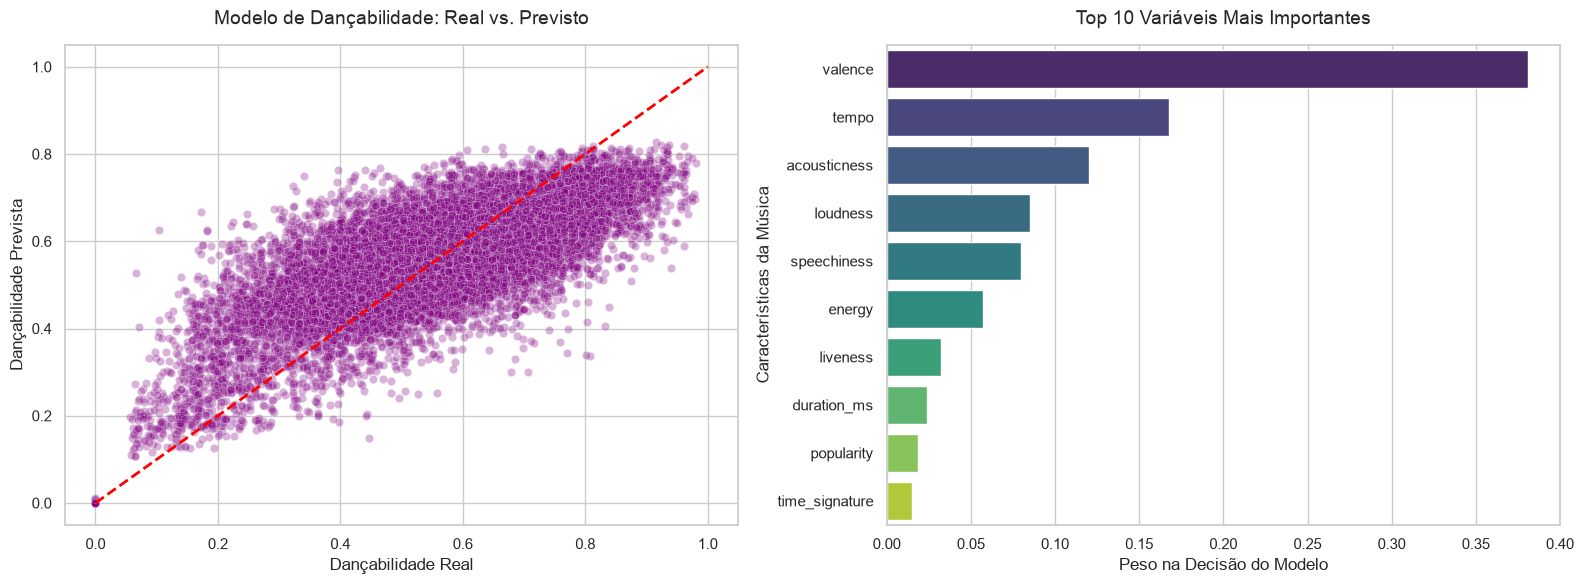

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# 1. Gera as previsões usando o modelo correto treinado com os dados novos
y_pred_dance = modelo_rf_dance.predict(X_test_scaled_d)

# Configuração visual geral
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico 1: Real vs Previsto ---
# Ambos os eixos agora estarão na mesma escala (0 a 1)
sns.scatterplot(x=y_test_d, y=y_pred_dance, alpha=0.3, color='purple', ax=axes[0])
axes[0].plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=2)
axes[0].set_title('Modelo de Dançabilidade: Real vs. Previsto', fontsize=14, pad=15)
axes[0].set_xlabel('Dançabilidade Real', fontsize=12)
axes[0].set_ylabel('Dançabilidade Prevista', fontsize=12)
axes[0].set_xlim(-0.05, 1.05)
axes[0].set_ylim(-0.05, 1.05)

# --- Gráfico 2: Importância das Variáveis (Feature Importance) ---
# Puxa a importância do modelo novo treinado sem vazamento de dados
importancias = modelo_rf_dance.feature_importances_
nomes_features = X_dance.columns
indices_ordenados = np.argsort(importancias)[::-1]
importancias_ordenadas = importancias[indices_ordenados]
features_ordenadas = [nomes_features[i] for i in indices_ordenados]

sns.barplot(
    x=importancias_ordenadas[:10], 
    y=features_ordenadas[:10], 
    hue=features_ordenadas[:10],  
    palette='viridis', 
    legend=False,                 
    ax=axes[1]
)
axes[1].set_title('Top 10 Variáveis Mais Importantes', fontsize=14, pad=15)
axes[1].set_xlabel('Peso na Decisão do Modelo', fontsize=12)
axes[1].set_ylabel('Características da Música', fontsize=12)

plt.tight_layout()

# Salva a imagem
caminho_pasta = 'outputs/figures'
os.makedirs(caminho_pasta, exist_ok=True)
plt.savefig(f'{caminho_pasta}/03_performance_danceability.png', dpi=300, bbox_inches='tight')

print(f"✅ Imagem salva com sucesso na pasta: {os.path.abspath(caminho_pasta)}")
plt.show()